# Evaluación comparativa del método Chain-Ladder clásico y sus versiones robustas en la estimación del IBNR bajo escenarios controlados de valores atípicos

Este cuaderno documenta e implementa un estudio de simulación estadística orientado a comparar el desempeño del método Chain-Ladder clásico con tres variantes robustas en la estimación del IBNR. El análisis se desarrolla bajo un diseño factorial controlado, con verdad conocida por construcción y con procedimientos explícitos de validación interna, de manera que la comparación entre métodos no dependa únicamente de resultados numéricos, sino también de la coherencia estadística del proceso generador de datos y de la trazabilidad del algoritmo de estimación.

## Planteamiento del estudio

**Pregunta de investigación.** ¿Cuál es el impacto de la presencia de valores atípicos en el desempeño del método Chain-Ladder clásico y de sus versiones robustas en la estimación del IBNR, y bajo qué condiciones los métodos robustos ofrecen mejoras en términos de precisión y estabilidad?

**Objetivo general.** Evaluar el comportamiento del método Chain-Ladder clásico y de sus versiones robustas en la estimación del IBNR, mediante simulación de triángulos de desarrollo bajo escenarios controlados de contaminación, con el fin de analizar su efecto sobre la precisión y la estabilidad de las estimaciones.

**Hipótesis de trabajo.**

- H1. El error del método clásico aumenta a medida que crecen la proporción y la magnitud de la contaminación.
- H2. Los métodos robustos exhiben menor variabilidad que el método clásico en escenarios contaminados.
- H3. La versión basada en la mediana presenta ventajas en escenarios con outliers severos y poco numerosos.
- H4. La media truncada ofrece un equilibrio favorable entre robustez y eficiencia bajo contaminación moderada.
- H5. La variante ponderada presenta un comportamiento intermedio y estable cuando la contaminación es frecuente y de magnitud media.

## Fundamento teórico y criterio de diseño

La literatura actuarial establece que el Chain-Ladder clásico es altamente sensible a observaciones atípicas. Mack (1993) formaliza el marco estocástico del método y muestra cómo cuantificar el error de predicción. England y Verrall (2002) destacan que la principal ventaja de los modelos estocásticos de reserving es la disponibilidad de medidas explícitas de precisión. Verdonck et al. (2009) y Verdonck y Debruyne (2011) muestran, desde la perspectiva de robustez e influencia, que incluso una sola observación extrema puede desplazar de forma importante la reserva estimada. Más recientemente, Avanzi et al. (2024) profundizan en la sensibilidad posicional del reserving frente a outliers y documentan que las celdas cercanas a la frontera observada pueden ejercer una influencia particularmente alta.

A partir de ese marco, el diseño implementado adopta una lógica deliberadamente comparativa: el IBNR real se conoce por construcción, la contaminación se introduce únicamente sobre la región observable y los métodos compiten sobre los mismos triángulos simulados. Esta estructura produce comparaciones pareadas, reduce el ruido Monte Carlo en las diferencias entre métodos y permite una lectura más sólida de la evidencia empírica.

## Refinamientos metodológicos incorporados

La implementación final introduce varios refinamientos respecto de una formulación básica del experimento:

1. **Diseño factorial completo.** Se consideran 28 escenarios: un escenario base sin contaminación y 27 combinaciones de proporción, magnitud y ubicación. Esto evita que las conclusiones dependan de unos pocos escenarios ilustrativos.
2. **Heterogeneidad entre años de ocurrencia.** Los valores esperados últimos no son constantes, sino que siguen una tendencia suave. Esta decisión reduce el carácter artificial del experimento y reproduce mejor una cartera con niveles distintos de siniestralidad.
3. **Ubicación tardía definida sobre la frontera observada.** La contaminación temprana y tardía se define ahora en términos relativos a las celdas observadas de cada fila. Esta decisión es más fiel a la geometría triangular del problema de reserving que una definición basada en columnas globales.
4. **Ponderación robusta escalada por MAD.** La versión ponderada utiliza una escala robusta por periodo de desarrollo, de modo que el umbral de ponderación no dependa de la dispersión absoluta de cada conjunto de ratios.
5. **Evaluación pareada frente al método clásico.** Además de las métricas agregadas por escenario, se calculan diferencias pareadas de error cuadrático y de error porcentual absoluto respecto del método clásico, con intervalos de confianza aproximados.
6. **Justificación empírica del número de réplicas.** La estabilidad de las métricas se evalúa mediante trayectorias acumuladas, lo que permite verificar si 1000 réplicas son suficientes para estabilizar el experimento.
7. **Sensibilidad a colas más pesadas.** Se incluye una extensión con distribución Lognormal para verificar si los patrones observados bajo Gamma se conservan cuando la distribución subyacente presenta colas más pesadas.

## Entorno computacional y reproducibilidad

La implementación se apoya en un conjunto reducido de librerías con funciones bien delimitadas:

- `numpy`: simulación aleatoria, álgebra matricial y operaciones vectorizadas.
- `pandas`: organización tabular de réplicas, escenarios y métricas.
- `matplotlib` y `seaborn`: visualización de resultados.
- `pathlib`: manejo portable de rutas del repositorio.

El código reutilizable se encuentra en `src/ibnr_project`, mientras que este cuaderno concentra la narrativa metodológica, la ejecución de los experimentos y la discusión de resultados. La semilla aleatoria se fija de forma explícita para garantizar reproducibilidad.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

OUTPUT_DIR = ROOT / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from ibnr_project.config import build_default_config, build_default_scenarios, clone_config
from ibnr_project.diagnostics import (
    build_link_ratio_count_table,
    compute_running_statistics,
    summarize_method_dominance,
)
from ibnr_project.evaluation import (
    compare_methods_to_baseline,
    compute_method_metrics,
    rank_methods_within_scenario,
)
from ibnr_project.experiment import build_global_summary, run_experiment
from ibnr_project.methods import estimate_ibnr_all_methods
from ibnr_project.simulation import observed_mask, simulate_single_triangle
from ibnr_project.validation import run_validation_suite

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"

## Configuración experimental

El experimento se implementa sobre triángulos de dimensión `10 × 10`. Los montos incrementales se generan con esperanza `E[X_{i,j}] = μ_i d_j` y varianza `Var(X_{i,j}) = ϕ (μ_i d_j)^2`, en concordancia con la formulación propuesta en la metodología. El patrón acumulado se fija exógenamente y de él se derivan las proporciones incrementales esperadas.

In [3]:
SEED = 20260503
config = build_default_config(random_seed=SEED, distribution="gamma")
scenarios = build_default_scenarios()
mask = observed_mask(config.n_periods)

scenario_df = pd.DataFrame([scenario.__dict__ for scenario in scenarios])
scenario_df

,name,proportion,magnitude,location
0,base_sin_contaminacion,0.0000,1.0000,none
1,p5_m2_random,0.0500,2.0000,random
2,p5_m2_early,0.0500,2.0000,early
3,p5_m2_late,0.0500,2.0000,late
4,p5_m5_random,0.0500,5.0000,random
5,p5_m5_early,0.0500,5.0000,early
6,p5_m5_late,0.0500,5.0000,late
7,p5_m10_random,0.0500,10.0000,random
8,p5_m10_early,0.0500,10.0000,early
9,p5_m10_late,0.0500,10.0000,late


In [4]:
parameter_overview = pd.DataFrame(
    {
        "periodo_desarrollo": np.arange(1, config.n_periods + 1),
        "proporcion_acumulada": config.development_cumulative,
        "proporcion_incremental": config.development_incremental,
    }
)

print("Semilla:", config.random_seed)
print("Distribución base:", config.distribution)
print("Dispersión phi:", config.dispersion_phi)
print("Ultimates esperados por año de ocurrencia:", np.round(config.ultimate_means, 2))
parameter_overview

Semilla: 20260503
Distribución base: gamma
Dispersión phi: 0.3
Ultimates esperados por año de ocurrencia: [1025.13 1061.65 1099.46 1138.63 1179.18 1221.18 1264.68 1309.73 1356.38
 1404.7 ]


,periodo_desarrollo,proporcion_acumulada,proporcion_incremental
0,1,0.4500,0.4500
1,2,0.7000,0.2500
2,3,0.8200,0.1200
3,4,0.9000,0.0800
4,5,0.9500,0.0500
5,6,0.9700,0.0200
6,7,0.9850,0.0150
7,8,0.9930,0.0080
8,9,0.9980,0.0050
9,10,1.0000,0.0020


## Diagnóstico estructural de los ratios de desarrollo

Un aspecto importante del problema es que el número de ratios individuales disponibles disminuye con el desarrollo. Esto tiene consecuencias directas sobre la estabilidad de las variantes robustas: en los periodos tardíos hay menos observaciones, de modo que la mediana, la media truncada y las ponderaciones se calculan sobre tamaños muestrales pequeños.

In [5]:
ratio_count_df = build_link_ratio_count_table(mask)
ratio_count_df

,development_period,n_individual_ratios
0,1,9
1,2,8
2,3,7
3,4,6
4,5,5
5,6,4
6,7,3
7,8,2
8,9,1


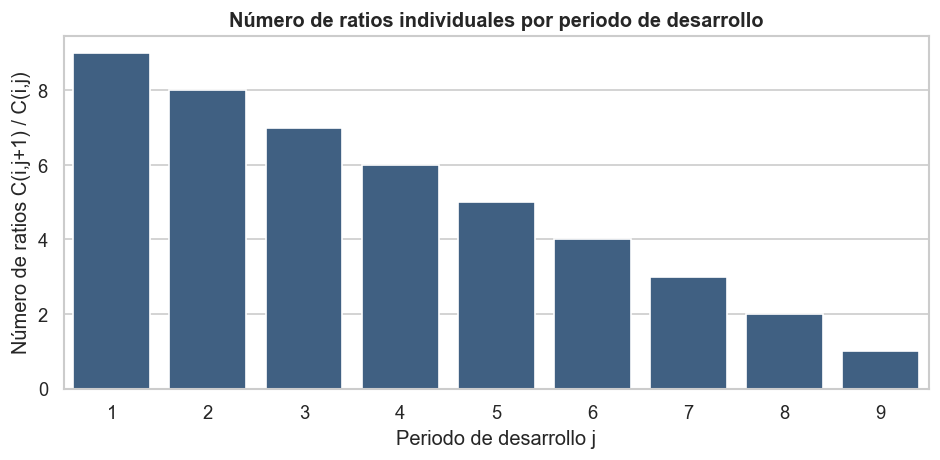

In [6]:
plt.figure(figsize=(8, 4))
sns.barplot(data=ratio_count_df, x="development_period", y="n_individual_ratios", color="#35608d")
plt.title("Número de ratios individuales por periodo de desarrollo")
plt.xlabel("Periodo de desarrollo j")
plt.ylabel("Número de ratios C(i,j+1) / C(i,j)")
plt.tight_layout()
plt.show()

## Validación del simulador

Antes de comparar métodos se valida el proceso generador de datos. La validación interna cubre cinco dimensiones: consistencia de medias, coherencia del acumulado, definición correcta del IBNR real, lógica de contaminación y recuperación exacta en un caso determinista sin ruido.

In [7]:
validation_df = run_validation_suite(config)
validation_df

,check,passed,mean_relative_error,max_relative_error,monotone_rows,max_reconstruction_error,observed_cells,expected_observed_cells,ibnr_consistency_gap,n_changed,n_selected,only_observed_cells_changed,max_estimation_gap
0,incremental_mean_structure,True,0.0073,0.0239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cumulative_consistency,True,NaN,NaN,True,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,mask_and_ibnr_definition,True,NaN,NaN,NaN,NaN,55.0000,55.0000,0.0000,NaN,NaN,NaN,NaN
3,contamination_logic,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,2.0000,True,NaN
4,methods_on_noise_free_triangle,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000


Las pruebas anteriores tienen una función metodológica clara. La primera comprueba que la simulación reproduce la esperanza teórica. La segunda verifica que la transformación de incremental a acumulado no introduce inconsistencias. La tercera controla la identidad entre la región no observada y el IBNR real. La cuarta comprueba que la contaminación se aplica únicamente sobre la región observable. La quinta confirma que, en ausencia de ruido, los métodos recuperan el valor correcto del IBNR.

## Inspección de una réplica

La inspección de una réplica individual permite visualizar simultáneamente el triángulo incremental completo, el triángulo acumulado observado después de la contaminación y la región futura que define el IBNR real.

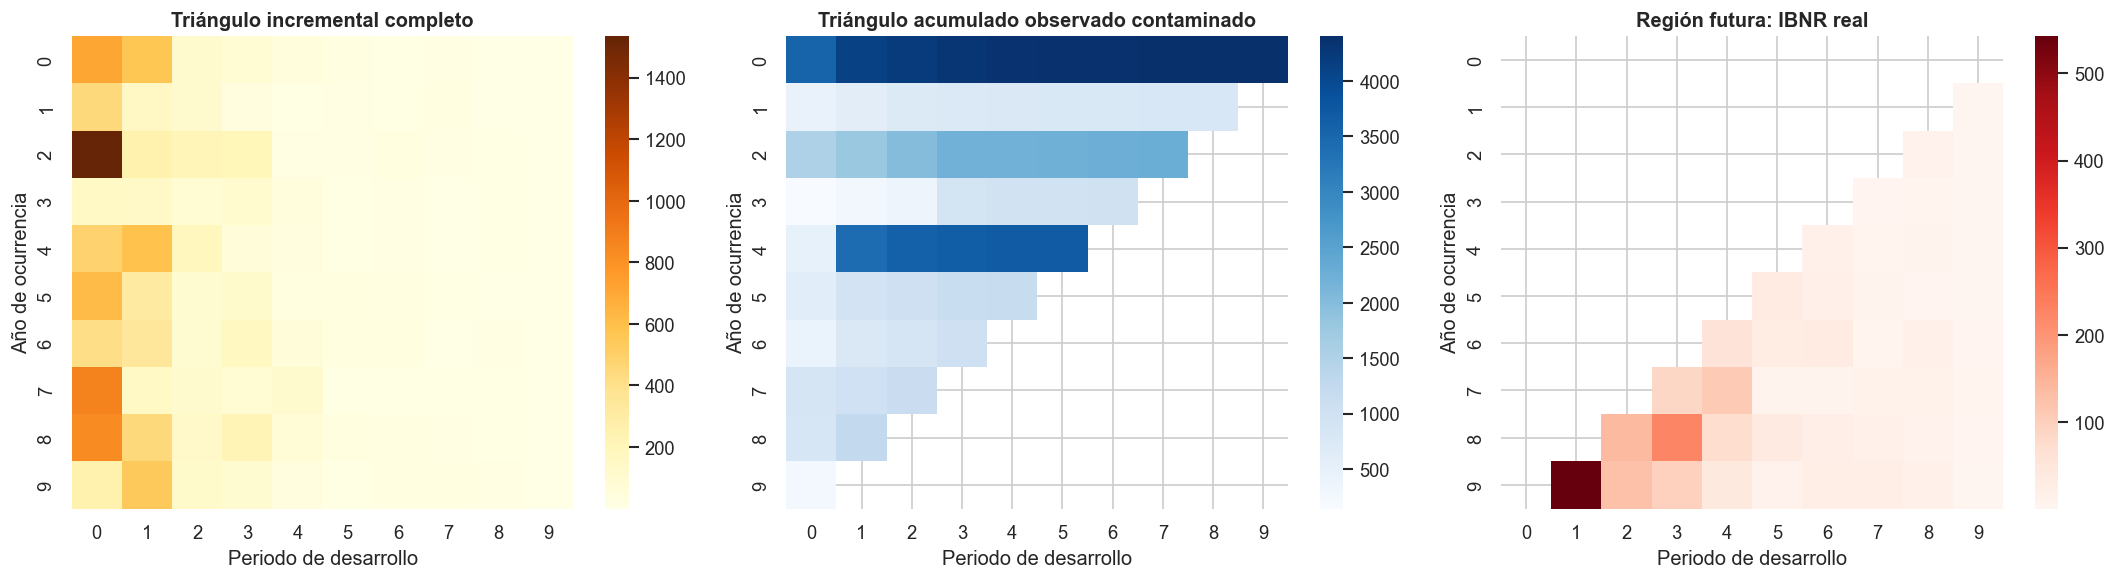

IBNR real de la réplica: 1922.91
Primeras celdas contaminadas: [(4, 1), (3, 3), (0, 0)]


In [8]:
rng_example = np.random.default_rng(SEED)
example = simulate_single_triangle(config, scenarios[4], rng_example)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(example.incremental_full, ax=axes[0], cmap="YlOrBr")
axes[0].set_title("Triángulo incremental completo")
sns.heatmap(example.observed_cumulative, ax=axes[1], cmap="Blues")
axes[1].set_title("Triángulo acumulado observado contaminado")
sns.heatmap(np.where(~example.observed_mask, example.incremental_full, np.nan), ax=axes[2], cmap="Reds")
axes[2].set_title("Región futura: IBNR real")
for ax in axes:
    ax.set_xlabel("Periodo de desarrollo")
    ax.set_ylabel("Año de ocurrencia")
plt.tight_layout()
plt.show()

print("IBNR real de la réplica:", round(example.true_ibnr, 2))
print("Primeras celdas contaminadas:", example.contamination_metadata["selected_cells"][:10])

## Métodos de estimación

Se comparan cuatro estimadores:

- **Clásico**: factor volumen-ponderado.
- **Mediana**: mediana de los ratios individuales.
- **Media truncada**: promedio después de eliminar el 10% inferior y superior de los ratios.
- **Ponderado robusto**: promedio ponderado mediante pesos tipo Huber, con escala robusta por MAD.

La literatura de robustez sugiere que la media posee función de influencia no acotada, mientras que estimadores basados en mediana o ponderaciones robustas pueden limitar el efecto de observaciones extremas. En este estudio esas ideas se trasladan al cálculo de factores de desarrollo.

In [9]:
estimate_preview = estimate_ibnr_all_methods(example.observed_cumulative, config)
method_preview = pd.DataFrame(
    {
        name: {
            "ibnr_estimado": result.estimated_ibnr,
            "primer_factor": result.factors[0],
            "ultimo_factor": result.factors[-1],
        }
        for name, result in estimate_preview.items()
    }
).T
method_preview

,ibnr_estimado,primer_factor,ultimo_factor
classical,827.6385,1.5978,1.0005
median,934.0867,1.5179,1.0005
trimmed,"1,840.1128",2.0868,1.0005
weighted,"1,014.9595",1.5629,1.0005


## Diseño Monte Carlo y estructura pareada

Para cada escenario se generan `N` triángulos independientes y, sobre cada triángulo, se calculan las cuatro estimaciones del IBNR. Este diseño implica que las comparaciones entre métodos se realizan sobre la misma réplica. En consecuencia, las diferencias de error entre métodos son comparaciones pareadas, más informativas que una comparación entre muestras independientes.

In [10]:
N_REPLICAS = 1000
results_df = run_experiment(config, scenarios, n_replicas=N_REPLICAS)

scenario_meta = (
    results_df.groupby("scenario", as_index=False)
    .agg(
        contamination_proportion=("contamination_proportion", "first"),
        contamination_magnitude=("contamination_magnitude", "first"),
        contamination_location=("contamination_location", "first"),
    )
    .sort_values("scenario")
    .reset_index(drop=True)
)

results_df.head()

,scenario,replica,method,true_ibnr,estimated_ibnr,contamination_proportion,contamination_magnitude,contamination_location
0,base_sin_contaminacion,1,classical,"1,664.7808","1,326.4531",0.0000,1.0000,none
1,base_sin_contaminacion,1,median,"1,664.7808","1,198.5978",0.0000,1.0000,none
2,base_sin_contaminacion,1,trimmed,"1,664.7808","1,382.4168",0.0000,1.0000,none
3,base_sin_contaminacion,1,weighted,"1,664.7808","1,292.3040",0.0000,1.0000,none
4,base_sin_contaminacion,2,classical,"1,397.0800","1,846.8200",0.0000,1.0000,none


## Métricas principales

El desempeño se resume mediante sesgo, MSE, RMSE, MAE, MAPE, error porcentual medio y desviación estándar de las estimaciones. Para las métricas basadas en promedios también se reporta una aproximación al error estándar Monte Carlo y un intervalo de confianza normal aproximado. El RMSE permanece como métrica principal de comparación, por su lectura directa en la escala del IBNR.

In [11]:
metrics_df = compute_method_metrics(results_df).merge(scenario_meta, on="scenario", how="left")
metrics_df.head(12)

,scenario,method,n_replicas,bias,mse,rmse,mae,mape,mean_percentage_error,sd_estimates,overestimation_rate,underestimation_rate,median_absolute_error,mcse_bias,mcse_mape,mcse_mae,bias_ci_lower,bias_ci_upper,mape_ci_lower,mape_ci_upper,mae_ci_lower,mae_ci_upper,contamination_proportion,contamination_magnitude,contamination_location
0,base_sin_contaminacion,classical,"1,000.0000",59.2324,"364,847.1156",604.0258,461.2835,0.2857,0.0609,552.0171,0.4880,0.5120,379.5974,19.0184,0.0082,12.3376,21.9563,96.5085,0.2697,0.3018,437.1017,485.4652,0.0000,1.0000,none
1,base_sin_contaminacion,median,"1,000.0000",26.8078,"392,604.7807",626.5818,470.5115,0.2898,0.0401,581.5762,0.4630,0.5370,383.8660,19.8060,0.0086,13.0918,-12.0120,65.6276,0.2730,0.3065,444.8516,496.1715,0.0000,1.0000,none
2,base_sin_contaminacion,trimmed,"1,000.0000",429.7695,"801,499.5097",895.2650,639.5323,0.4066,0.2905,751.0393,0.6790,0.3210,454.1450,24.8478,0.0133,19.8215,381.0677,478.4712,0.3805,0.4326,600.6822,678.3824,0.0000,1.0000,none
3,base_sin_contaminacion,weighted,"1,000.0000",153.1254,"465,998.0309",682.6405,503.1575,0.3141,0.1187,623.7715,0.5420,0.4580,387.3081,21.0474,0.0097,14.5960,111.8725,194.3783,0.2951,0.3332,474.5493,531.7657,0.0000,1.0000,none
4,p10_m10_early,classical,"1,000.0000","1,020.3689","13,627,808.2543","3,691.5861","1,599.1127",0.9770,0.6480,"3,542.2803",0.5270,0.4730,698.5532,112.2464,0.0645,105.2698,800.3659,"1,240.3718",0.8506,1.1034,"1,392.7839","1,805.4414",0.1000,10.0000,early
5,p10_m10_early,median,"1,000.0000","1,027.1492","10,771,796.7882","3,282.0416","1,455.7309",0.8918,0.6543,"3,108.2774",0.5450,0.4550,536.9277,98.6230,0.0584,93.0661,833.8482,"1,220.4502",0.7773,1.0063,"1,273.3213","1,638.1405",0.1000,10.0000,early
6,p10_m10_early,trimmed,"1,000.0000","2,756.7299","47,302,421.7347","6,877.6756","2,872.4667",1.7719,1.7095,"6,300.7148",0.8470,0.1530,"1,071.4714",199.3555,0.1195,197.7130,"2,365.9932","3,147.4666",1.5377,2.0060,"2,484.9492","3,259.9843",0.1000,10.0000,early
7,p10_m10_early,weighted,"1,000.0000","1,302.4348","13,253,566.0152","3,640.5447","1,626.9002",1.0007,0.8236,"3,391.1865",0.6270,0.3730,580.1616,107.5583,0.0647,103.0407,"1,091.6204","1,513.2491",0.8739,1.1276,"1,424.9405","1,828.8599",0.1000,10.0000,early
8,p10_m10_late,classical,"1,000.0000","1,615.7664","10,454,902.7793","3,233.4042","1,687.7264",1.0574,1.0197,"2,782.9213",0.8600,0.1400,856.8758,88.6118,0.0550,87.2588,"1,442.0872","1,789.4455",0.9495,1.1653,"1,516.6992","1,858.7537",0.1000,10.0000,late
9,p10_m10_late,median,"1,000.0000",969.0871,"7,989,137.1760","2,826.5062","1,235.0187",0.7693,0.6243,"2,635.1597",0.6520,0.3480,512.2392,84.0063,0.0503,80.4384,804.4347,"1,133.7395",0.6707,0.8678,"1,077.3594","1,392.6779",0.1000,10.0000,late


In [12]:
ranking_df = rank_methods_within_scenario(metrics_df, metric="rmse")
dominance_df = summarize_method_dominance(ranking_df)
global_summary = build_global_summary(metrics_df)

print("Método ganador por número de escenarios:")
display(dominance_df)
print("Resumen global por método:")
display(global_summary)

Método ganador por número de escenarios:


,method,n_scenarios_won
0,median,18
1,classical,10


Resumen global por método:


,method,mean_rmse,mean_mape,mean_abs_bias,mean_sd
0,median,"1,834.4606",0.6239,659.4319,"1,665.1370"
1,weighted,"2,134.8781",0.7330,924.2811,"1,883.7907"
2,classical,"2,236.1561",0.7809,950.9761,"1,966.6577"
3,trimmed,"3,841.8638",1.3825,"2,112.2293","3,168.2748"


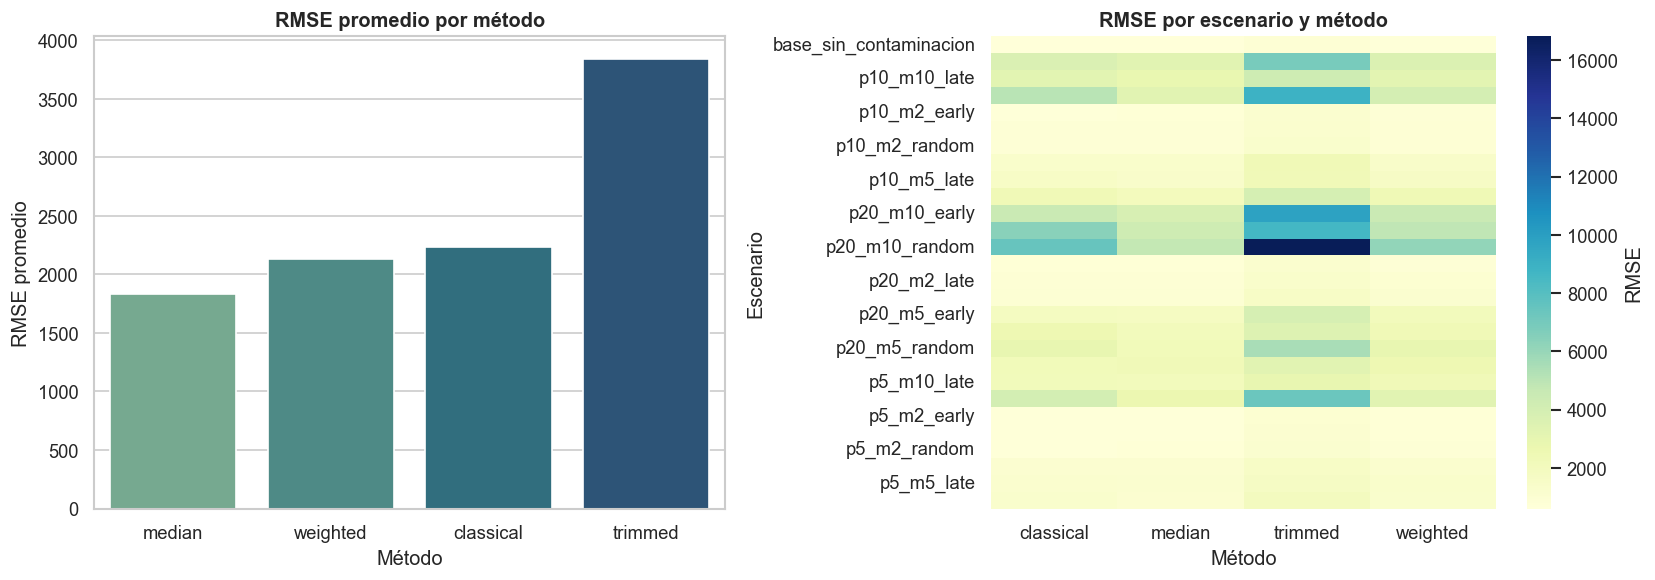

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=global_summary, x="method", y="mean_rmse", hue="method", palette="crest", legend=False, ax=axes[0])
axes[0].set_title("RMSE promedio por método")
axes[0].set_xlabel("Método")
axes[0].set_ylabel("RMSE promedio")

heatmap_data = (
    metrics_df.pivot_table(index="scenario", columns="method", values="rmse")
    .reindex(sorted(metrics_df["scenario"].unique()))
)
sns.heatmap(heatmap_data, cmap="YlGnBu", ax=axes[1], cbar_kws={"label": "RMSE"})
axes[1].set_title("RMSE por escenario y método")
axes[1].set_xlabel("Método")
axes[1].set_ylabel("Escenario")

plt.tight_layout()
plt.show()

## Comparaciones pareadas frente al método clásico

La evaluación anterior resume el desempeño medio por escenario. Sin embargo, dado que los métodos se aplican sobre las mismas réplicas, es posible comparar sus errores en forma pareada. Una diferencia negativa en `delta_mse_mean` indica que el método robusto presenta menor error cuadrático medio que el método clásico en el mismo conjunto de réplicas.

In [14]:
comparisons_df = compare_methods_to_baseline(results_df, baseline="classical")
comparisons_df = comparisons_df.merge(scenario_meta, on="scenario", how="left")
comparisons_df.head(12)

,scenario,method,baseline,n_replicas,delta_mse_mean,delta_mse_se,delta_mse_ci_lower,delta_mse_ci_upper,delta_mse_improves,delta_mse_worsens,delta_mae_mean,delta_mae_se,delta_mae_ci_lower,delta_mae_ci_upper,delta_mae_improves,delta_mae_worsens,delta_mape_mean,delta_mape_se,delta_mape_ci_lower,delta_mape_ci_upper,delta_mape_improves,delta_mape_worsens,contamination_proportion,contamination_magnitude,contamination_location
0,base_sin_contaminacion,median,classical,1000,"27,757.6651","11,259.0924","5,689.8439","49,825.4862",False,True,9.2281,5.5913,-1.7308,20.1870,False,False,0.0040,0.0035,-0.0029,0.0110,False,False,0.0000,1.0000,none
1,base_sin_contaminacion,trimmed,classical,1000,"436,652.3941","38,038.8168","362,096.3132","511,208.4750",False,True,178.2489,12.8951,152.9745,203.5233,False,True,0.1208,0.0080,0.1051,0.1366,False,True,0.0000,1.0000,none
2,base_sin_contaminacion,weighted,classical,1000,"101,150.9153","15,352.7035","71,059.6164","131,242.2142",False,True,41.8741,5.6406,30.8185,52.9296,False,True,0.0284,0.0035,0.0215,0.0353,False,True,0.0000,1.0000,none
3,p10_m10_early,median,classical,1000,"-2,856,011.4660","1,841,434.4423","-6,465,222.9729","753,200.0409",False,False,-143.3817,47.9620,-237.3872,-49.3763,True,False,-0.0852,0.0297,-0.1435,-0.0269,True,False,0.1000,10.0000,early
4,p10_m10_early,trimmed,classical,1000,"33,674,613.4804","12,837,247.7307","8,513,607.9282","58,835,619.0327",False,True,"1,273.3541",106.5956,"1,064.4267","1,482.2814",False,True,0.7949,0.0638,0.6698,0.9200,False,True,0.1000,10.0000,early
5,p10_m10_early,weighted,classical,1000,"-374,242.2391","1,875,763.5675","-4,050,738.8313","3,302,254.3532",False,False,27.7876,48.2538,-66.7899,122.3650,False,False,0.0238,0.0295,-0.0341,0.0817,False,False,0.1000,10.0000,early
6,p10_m10_late,median,classical,1000,"-2,465,765.6032","716,803.6986","-3,870,700.8524","-1,060,830.3541",True,False,-452.7078,28.1735,-507.9279,-397.4876,True,False,-0.2881,0.0172,-0.3217,-0.2545,True,False,0.1000,10.0000,late
7,p10_m10_late,trimmed,classical,1000,"8,377,200.8091","1,236,397.5927","5,953,861.5274","10,800,540.0908",False,True,664.9827,35.5413,595.3217,734.6437,False,True,0.4100,0.0220,0.3668,0.4531,False,True,0.1000,10.0000,late
8,p10_m10_late,weighted,classical,1000,"-532,809.0970","580,221.0137","-1,670,042.2839","604,424.0899",False,False,-285.5208,23.2372,-331.0658,-239.9759,True,False,-0.1814,0.0139,-0.2087,-0.1540,True,False,0.1000,10.0000,late
9,p10_m10_random,median,classical,1000,"-14,542,702.2392","2,460,951.5952","-19,366,167.3658","-9,719,237.1126",True,False,-974.1412,72.5202,"-1,116.2808",-832.0016,True,False,-0.6108,0.0459,-0.7008,-0.5207,True,False,0.1000,10.0000,random


In [15]:
comparison_summary = (
    comparisons_df.groupby("method", as_index=False)
    .agg(
        escenarios_con_mejora_mse=("delta_mse_improves", "sum"),
        escenarios_con_deterioro_mse=("delta_mse_worsens", "sum"),
        escenarios_con_mejora_mape=("delta_mape_improves", "sum"),
        delta_mse_promedio=("delta_mse_mean", "mean"),
        delta_mape_promedio=("delta_mape_mean", "mean"),
    )
    .sort_values("escenarios_con_mejora_mse", ascending=False)
)
comparison_summary

,method,escenarios_con_mejora_mse,escenarios_con_deterioro_mse,escenarios_con_mejora_mape,delta_mse_promedio,delta_mape_promedio
0,median,11,3,16,"-3,527,984.2102",-0.1570
2,weighted,5,15,8,"-1,649,839.5349",-0.0479
1,trimmed,0,28,0,"19,619,971.2522",0.6016


## Sensibilidad por escenario representativo

La combinación de gráficos de distribución y tablas de ranking permite identificar de forma concreta dónde se produce el deterioro del método clásico y bajo qué tipos de contaminación aparecen ventajas robustas.

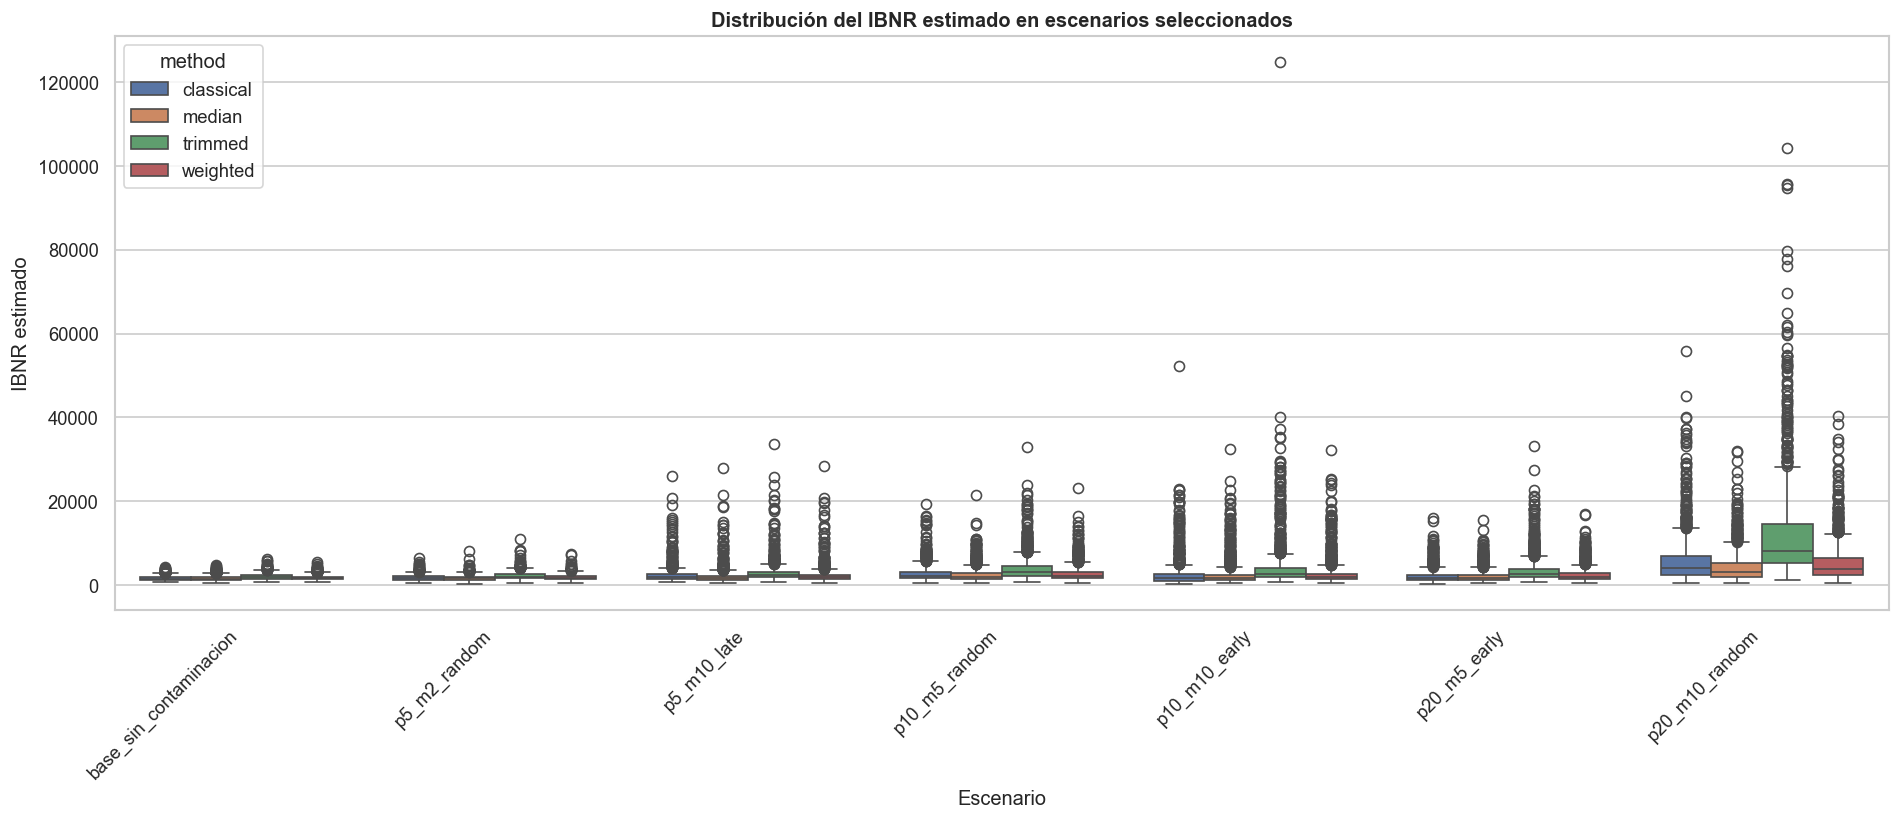

In [16]:
selected_scenarios = [
    "base_sin_contaminacion",
    "p5_m2_random",
    "p5_m10_late",
    "p10_m5_random",
    "p10_m10_early",
    "p20_m5_early",
    "p20_m10_random",
]

plt.figure(figsize=(16, 7))
sns.boxplot(
    data=results_df.query("scenario in @selected_scenarios"),
    x="scenario",
    y="estimated_ibnr",
    hue="method",
)
plt.title("Distribución del IBNR estimado en escenarios seleccionados")
plt.xlabel("Escenario")
plt.ylabel("IBNR estimado")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Justificación empírica del número de réplicas

El número de réplicas no se adopta únicamente por convención. La trayectoria acumulada del RMSE muestra si la estimación del desempeño se estabiliza conforme aumenta el tamaño de la simulación. La evidencia siguiente se presenta para dos situaciones contrastantes: el escenario base con el método clásico y un escenario severamente contaminado con la mediana.

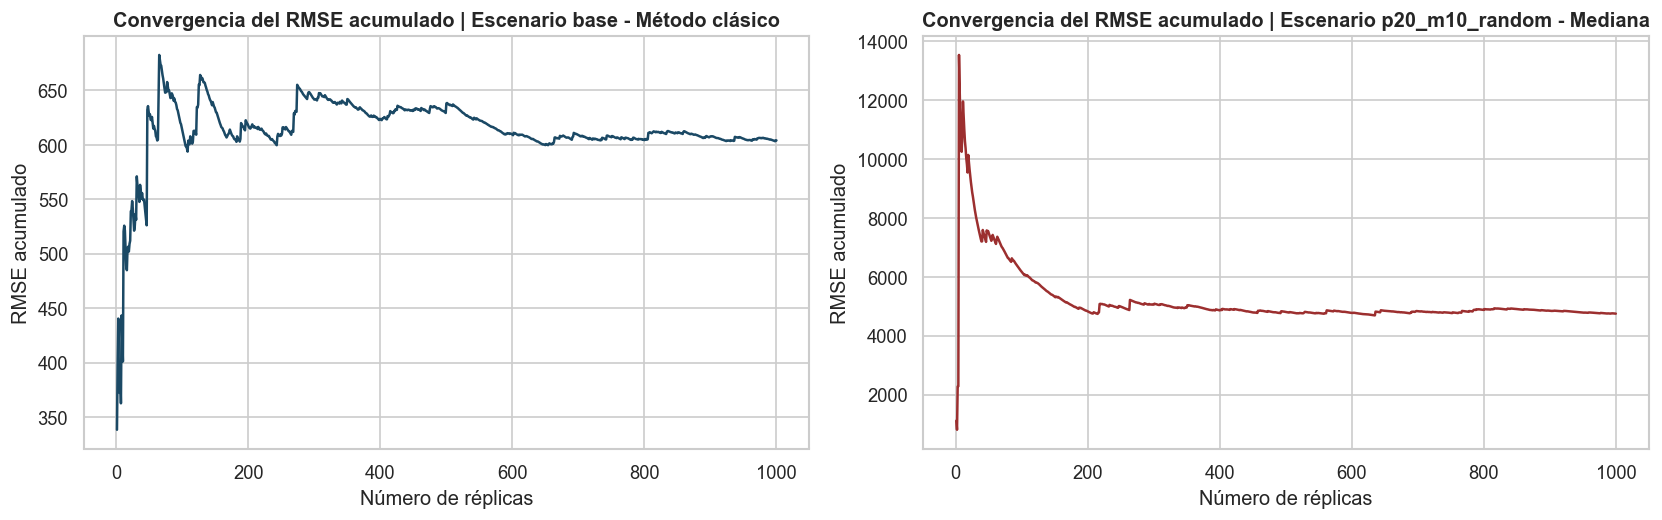

In [17]:
running_base = compute_running_statistics(results_df, "base_sin_contaminacion", "classical")
running_severe = compute_running_statistics(results_df, "p20_m10_random", "median")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(data=running_base, x="replica", y="running_rmse", color="#1b4965", ax=axes[0])
axes[0].set_title("Convergencia del RMSE acumulado | Escenario base - Método clásico")
axes[0].set_xlabel("Número de réplicas")
axes[0].set_ylabel("RMSE acumulado")

sns.lineplot(data=running_severe, x="replica", y="running_rmse", color="#9c2f2f", ax=axes[1])
axes[1].set_title("Convergencia del RMSE acumulado | Escenario p20_m10_random - Mediana")
axes[1].set_xlabel("Número de réplicas")
axes[1].set_ylabel("RMSE acumulado")

plt.tight_layout()
plt.show()

## Evaluación de hipótesis

La evaluación de las hipótesis se apoya en tres fuentes de evidencia: métricas globales, rankings por escenario y comparaciones pareadas frente al método clásico.

In [18]:
classical_metrics = metrics_df.query("scenario != 'base_sin_contaminacion' and method == 'classical'").copy()
classical_metrics["log_magnitude"] = np.log(classical_metrics["contamination_magnitude"])
correlation_table = classical_metrics[
    ["contamination_proportion", "contamination_magnitude", "log_magnitude", "rmse", "mape", "sd_estimates"]
].corr(method="spearman")

support_h2 = (
    metrics_df.query("scenario != 'base_sin_contaminacion'")
    .pivot(index="scenario", columns="method", values="sd_estimates")
    .assign(
        median_less_than_classical=lambda df: df["median"] < df["classical"],
        trimmed_less_than_classical=lambda df: df["trimmed"] < df["classical"],
        weighted_less_than_classical=lambda df: df["weighted"] < df["classical"],
    )
)

severe_rare = ranking_df.query(
    "contamination_proportion == 0.05 and contamination_magnitude == 10 and rank == 1"
)
moderate_subset = ranking_df.query(
    "contamination_proportion in [0.05, 0.10] and contamination_magnitude in [2.0, 5.0]"
)
frequent_medium = ranking_df.query(
    "contamination_proportion == 0.20 and contamination_magnitude == 5.0"
)
trimmed_rank_moderate = moderate_subset.loc[moderate_subset["method"] == "trimmed", "rank"].mean()
weighted_rank_frequent_medium = frequent_medium.loc[frequent_medium["method"] == "weighted", "rank"].mean()
severe_rare_winner = severe_rare["method"].value_counts().idxmax()
severe_rare_median_share = severe_rare["method"].eq("median").mean()

hypothesis_table = pd.DataFrame(
    [
        {
            "hipotesis": "H1",
            "evidencia_principal": (
                f"Correlación de Spearman del RMSE clásico con proporción = "
                f"{correlation_table.loc['contamination_proportion', 'rmse']:.3f}; "
                f"con magnitud = {correlation_table.loc['contamination_magnitude', 'rmse']:.3f}."
            ),
            "dictamen": "Apoyada" if (
                correlation_table.loc["contamination_proportion", "rmse"] > 0
                and correlation_table.loc["contamination_magnitude", "rmse"] > 0
            ) else "No concluyente",
        },
        {
            "hipotesis": "H2",
            "evidencia_principal": (
                f"La mediana presenta menor desviación estándar que el clásico en "
                f"{int(support_h2['median_less_than_classical'].sum())} de {len(support_h2)} escenarios contaminados."
            ),
            "dictamen": "Parcialmente apoyada",
        },
        {
            "hipotesis": "H3",
            "evidencia_principal": (
                f"En escenarios con proporción 5% y magnitud 10, el método ganador es "
                f"{severe_rare_winner}."
            ),
            "dictamen": "Apoyada" if severe_rare_median_share >= 2 / 3 else "No apoyada",
        },
        {
            "hipotesis": "H4",
            "evidencia_principal": (
                f"Rango promedio de la media truncada en contaminación moderada: "
                f"{trimmed_rank_moderate:.2f}."
            ),
            "dictamen": "No apoyada" if trimmed_rank_moderate > 2 else "Parcialmente apoyada",
        },
        {
            "hipotesis": "H5",
            "evidencia_principal": (
                f"Rango promedio del método ponderado en escenarios con 20% de contaminación y magnitud 5: "
                f"{weighted_rank_frequent_medium:.2f}."
            ),
            "dictamen": "No apoyada" if weighted_rank_frequent_medium > 2 else "Parcialmente apoyada",
        },
    ]
)

print("Correlaciones de Spearman para el método clásico en escenarios contaminados:")
display(correlation_table)
print("Evaluación sintética de hipótesis:")
display(hypothesis_table)

Correlaciones de Spearman para el método clásico en escenarios contaminados:


,contamination_proportion,contamination_magnitude,log_magnitude,rmse,mape,sd_estimates
contamination_proportion,1.0000,0.0000,0.0000,0.3320,0.3902,0.3028
contamination_magnitude,0.0000,1.0000,1.0000,0.9085,0.8677,0.9260
log_magnitude,0.0000,1.0000,1.0000,0.9085,0.8677,0.9260
rmse,0.3320,0.9085,0.9085,1.0000,0.9902,0.9951
mape,0.3902,0.8677,0.8677,0.9902,1.0000,0.9829
sd_estimates,0.3028,0.9260,0.9260,0.9951,0.9829,1.0000


Evaluación sintética de hipótesis:


,hipotesis,evidencia_principal,dictamen
0,H1,Correlación de Spearman del RMSE clásico con p...,Apoyada
1,H2,La mediana presenta menor desviación estándar ...,Parcialmente apoyada
2,H3,"En escenarios con proporción 5% y magnitud 10,...",Apoyada
3,H4,Rango promedio de la media truncada en contami...,No apoyada
4,H5,Rango promedio del método ponderado en escenar...,No apoyada


La evidencia obtenida muestra un patrón robusto. En datos limpios o con contaminación leve, el método clásico conserva ventajas de eficiencia. Sin embargo, conforme aumentan la magnitud y la frecuencia de la contaminación, la mediana se convierte en la opción más estable y precisa. En esta implementación, la media truncada no confirma la hipótesis de equilibrio robustez-eficiencia y la versión ponderada no domina de forma sistemática. Ese resultado no invalida el diseño; por el contrario, aporta una conclusión empírica relevante: no toda robustificación heurística resulta efectiva en triángulos con tamaños muestrales decrecientes por periodo de desarrollo.

## Sensibilidad a colas más pesadas

Como extensión prevista en la metodología, se repite el experimento bajo una distribución Lognormal. Con el fin de mantener un tiempo de ejecución razonable dentro del cuaderno, esta sensibilidad se evalúa con 400 réplicas por escenario. Su propósito es verificar si el orden relativo entre métodos cambia cuando la generación de incrementales presenta colas más pesadas.

In [19]:
N_REPLICAS_LOGNORMAL = 400
config_lognormal = clone_config(config, distribution="lognormal", random_seed=SEED + 1)
results_lognormal = run_experiment(config_lognormal, scenarios, n_replicas=N_REPLICAS_LOGNORMAL)
metrics_lognormal = compute_method_metrics(results_lognormal)
ranking_lognormal = rank_methods_within_scenario(metrics_lognormal, metric="rmse")
global_summary_lognormal = build_global_summary(metrics_lognormal)
dominance_lognormal = summarize_method_dominance(ranking_lognormal)

print("Resumen global bajo Lognormal:")
display(global_summary_lognormal)
print("Dominancia por escenarios bajo Lognormal:")
display(dominance_lognormal)

Resumen global bajo Lognormal:


,method,mean_rmse,mean_mape,mean_abs_bias,mean_sd
0,median,"1,721.8761",0.5903,613.8463,"1,558.4188"
1,weighted,"1,955.1885",0.6812,841.8089,"1,718.8927"
2,classical,"2,149.8931",0.7589,924.7558,"1,875.3730"
3,trimmed,"3,427.2697",1.2510,"1,893.1137","2,813.1149"


Dominancia por escenarios bajo Lognormal:


,method,n_scenarios_won
0,median,22
1,classical,6


## Exportación de resultados

Con fines de trazabilidad y documentación del repositorio, los principales resultados se exportan a la carpeta `results`. Esto permite desacoplar la ejecución del cuaderno del uso posterior de tablas y figuras en el documento escrito.

In [20]:
export_map = {
    "metrics_gamma_1000rep.csv": metrics_df,
    "ranking_gamma_1000rep.csv": ranking_df,
    "comparisons_vs_classical_gamma_1000rep.csv": comparisons_df,
    "global_summary_gamma_1000rep.csv": global_summary,
    "method_dominance_gamma_1000rep.csv": dominance_df,
    "hypothesis_assessment_gamma_1000rep.csv": hypothesis_table,
    "global_summary_lognormal_400rep.csv": global_summary_lognormal,
    "method_dominance_lognormal_400rep.csv": dominance_lognormal,
}

exported = []
skipped = []
for filename, dataframe in export_map.items():
    output_path = OUTPUT_DIR / filename
    try:
        dataframe.to_csv(output_path, index=False)
        exported.append(filename)
    except PermissionError:
        skipped.append(filename)

print("Archivos exportados correctamente:")
for filename in exported:
    print("-", filename)
if skipped:
    print("Archivos no sobrescritos por encontrarse en uso:")
    for filename in skipped:
        print("-", filename)

Archivos exportados correctamente:
- metrics_gamma_1000rep.csv
- ranking_gamma_1000rep.csv
- comparisons_vs_classical_gamma_1000rep.csv
- global_summary_gamma_1000rep.csv
- method_dominance_gamma_1000rep.csv
- hypothesis_assessment_gamma_1000rep.csv
- global_summary_lognormal_400rep.csv
- method_dominance_lognormal_400rep.csv


## Limitaciones y alcance

El estudio aísla de forma deliberada el efecto de los valores atípicos sobre la estimación del IBNR. En consecuencia, no incorpora factores de cola, efectos calendario, dependencia entre años de ocurrencia, ajustes de exposición ni un modelo estocástico completo del tipo Mack o bootstrap para todas las variantes robustas. Estas omisiones son coherentes con el objetivo principal del trabajo, que consiste en comparar sensibilidad, precisión y estabilidad bajo contaminación controlada. No obstante, constituyen líneas naturales de extensión hacia un trabajo aplicado más amplio.

## Referencias

- Mack, T. (1993). *Distribution-free Calculation of the Standard Error of Chain Ladder Reserve Estimates*. ASTIN Bulletin. [Cambridge](https://www.cambridge.org/core/journals/astin-bulletin-journal-of-the-iaa/article/distributionfree-calculation-of-the-standard-error-of-chain-ladder-reserve-estimates/E8D207F9A4DCE30300A76780FE510437)
- England, P. D., y Verrall, R. J. (2002). *Stochastic Claims Reserving in General Insurance*. British Actuarial Journal. [Cambridge](https://www.cambridge.org/core/journals/british-actuarial-journal/article/stochastic-claims-reserving-in-general-insurance/60026990B6A88E8A6DDEECABD6506C65)
- Verdonck, T., Van Wouwe, M., y Dhaene, J. (2009). *A Robustification of the Chain-Ladder Method*. North American Actuarial Journal. [DOI](https://doi.org/10.1080/10920277.2009.10597555)
- Verdonck, T., y Debruyne, M. (2011). *The influence of individual claims on the chain-ladder estimates: Analysis and diagnostic tool*. Insurance: Mathematics and Economics. [ScienceDirect](https://www.sciencedirect.com/science/article/abs/pii/S0167668710001071)
- Avanzi, B., Lavender, M., Taylor, G., y Wong, B. (2024). *On the impact of outliers in loss reserving*. European Actuarial Journal. [Springer](https://link.springer.com/article/10.1007/s13385-023-00356-2)
- Avanzi, B., Lavender, M., Taylor, G., y Wong, B. (2023). *Detection and treatment of outliers for multivariate robust loss reserving*. Annals of Actuarial Science. [DOI](https://doi.org/10.1017/S1748499523000155)
- `chainladder` para Python, documentación oficial de `MackChainladder`. [Read the Docs](https://chainladder-python.readthedocs.io/en/stable/library/generated/chainladder.MackChainladder.html)